Compute uncertainty by volume range. Following [this paper](https://www.sciencedirect.com/science/article/pii/S1361841519300994) we compute for three ranges: <5mL, >5mL and <15mL, >15mL.


In [1]:
dataset_path = '/home/fmatzkin/Code/datasets/wmh/'
utrecht_path = dataset_path + 'training/Utrecht'
amsterdam_path = dataset_path + 'training/Amsterdam'
singapore_path = dataset_path + 'training/Singapore'

predictions_model = 'training_Utrecht_Singapore_MEEP_2724_best'
file_name = f'pred_wmh_softmax_{predictions_model}.nii.gz'

In [2]:
def entropy(probs, eps=1e-3, apply_mean=True):
    probs = np.clip(probs, eps, 1 - eps)
    if apply_mean:
        return np.mean(-probs * np.log(probs) - (1 - probs) * np.log(1 - probs))
    else:
        return -probs * np.log(probs) - (1 - probs) * np.log(1 - probs)

In [3]:
# Get all predictions files
import os

softmax_files = {'utrecht': [], 'amsterdam': [],
                    'singapore': []}

for center, center_path in zip(['utrecht', 'amsterdam', 'singapore'],
                               [utrecht_path, amsterdam_path, singapore_path]):
    for path, subdirs, files in os.walk(center_path):
        for name in files:
            if name == file_name:
                softmax_files[center].append(os.path.join(path, name))

In [4]:
# Open the files and compute the uncertainty for each volume range
import numpy as np
import SimpleITK as sitk

wmh_entropies = {'utrecht': [], 'amsterdam': [],
               'singapore': []}

for center in ['utrecht', 'amsterdam', 'singapore']:
    l5, l15, g15 = [], [], []
    for sftmx_file in softmax_files[center]:
        softmax_img = sitk.ReadImage(sftmx_file)
        hard_pred = sitk.GetArrayFromImage(softmax_img).argmax(axis=0)

        # Get the connected components
        cc = sitk.ConnectedComponent(sitk.GetImageFromArray((hard_pred > 0).astype(np.uint8)))
        cc = sitk.RelabelComponent(cc)

        # For each connected component, compute the volume, then, append to the
        # corresponding list the entropy of the volume in that area.
        # (Multiply for the voxel size to get the volume in mL)
        for i in range(1, sitk.GetArrayFromImage(cc).max() + 1):
            cc_mask_f = sitk.GetArrayFromImage(cc == i).flatten()
            filt = np.where(cc_mask_f == 1)[0]
            volume = len(filt) * np.prod(softmax_img.GetSpacing())
            sftmx_f = sitk.GetArrayFromImage(softmax_img).flatten()[filt]
            # Compute entropy by first slicing the softmax image with the mask
            # and then computing the entropy of the slice
            ent = entropy(sftmx_f)
            if volume < 5:
                l5.append(ent)
            elif volume < 15:
                l15.append(ent)
            else:
                g15.append(ent)
    wmh_entropies[center] = {'l5': l5, 'l15': l15, 'g15': g15}

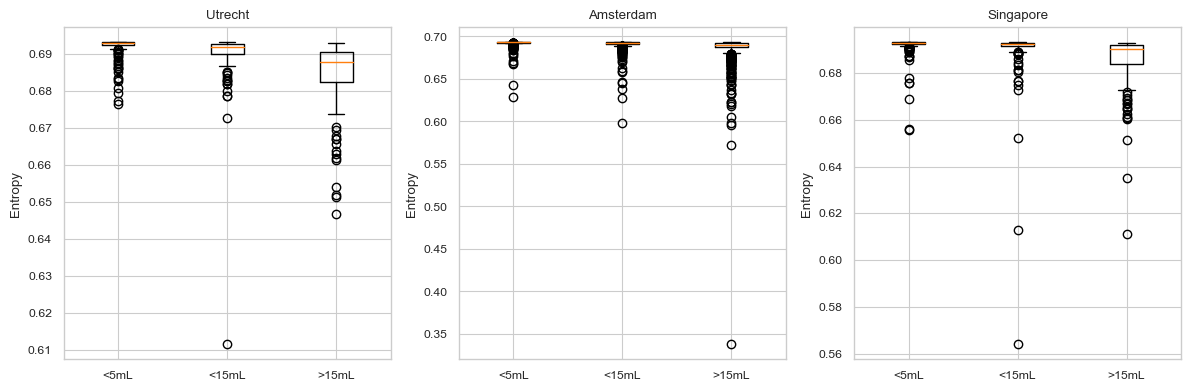

In [5]:
# Plot the results
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_context('paper')

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i, center in enumerate(['utrecht', 'amsterdam', 'singapore']):
    ax[i].boxplot([wmh_entropies[center]['l5'], wmh_entropies[center]['l15'],
                   wmh_entropies[center]['g15']])
    ax[i].set_xticklabels(['<5mL', '<15mL', '>15mL'])
    ax[i].set_title(center.capitalize())
    ax[i].set_ylabel('Entropy')

fig.tight_layout()